#### In this notebook we move to the DHS KR child data for all years we cleaned.  We pull out the height-for-age z-score wherever it is available, build a simple stunting flag (z < -2),  and then look at how stunting has changed over time in Ethiopia, Kenya, Tanzania, and Uganda.

In [201]:
import pandas as pd
import matplotlib.pyplot as plt

In [203]:
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]


#### Here we read each cleaned KR CSV, figure out the country from the file name, copy over the interview year as survey_year, and then stack everything into one table called children_all.


In [205]:
# we collect country, survey year, and height-for-age z-score for all files
child_rows = []

for fname in all_clean_files:
    print("reading:", fname)
    df = pd.read_csv(fname)
    
    # figure out country name from the file name (e.g. "Ethiopia_KR_1992_clean.csv")
    country_name = fname.split("_")[0]
    
    # survey year from the "interview year" column (this showed up in all files)
    if "interview year" in df.columns:
        survey_year = df["interview year"]
    elif "year_interview" in df.columns:
        survey_year = df["year_interview"]
    else:
        survey_year = pd.NA
    
    # only keep rows where the HAZ column exists
    if "height for age SD per WHO" in df.columns:
        tmp = pd.DataFrame({
            "country": country_name,
            "survey_year": survey_year,
            "haz": df["height for age SD per WHO"],
        })
        child_rows.append(tmp)
    else:
        print("   no HAZ column in this file, skip for stunting trends")


reading: Ethiopia_KR_1992_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Ethiopia_KR_1997_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Ethiopia_KR_2003_clean.csv
reading: Ethiopia_KR_2008_clean.csv
reading: Ethiopia_KR_2011_clean.csv
reading: Kenya_KR_89_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Kenya_KR_93_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Kenya_KR_98_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Kenya_KR_2003_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Kenya_KR_2009_clean.csv
reading: Kenya_KR_2014_clean.csv
reading: Kenya_KR_2022_clean.csv
reading: Tanzania_KR_92_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Tanzania_KR_96_clean.csv
   no HAZ column in this file, skip for stunting trends
reading: Tanzania_KR_99_clean.csv
   no HAZ column in this file, skip for stunt

In [209]:
# put all countries / years together
children_all_years = pd.concat(child_rows, ignore_index=True)

# drop rows with missing HAZ
children_all_years = children_all_years.dropna(subset=["haz"]).copy()

# stunted if HAZ < -2
children_all_years["is_stunted"] = children_all_years["haz"] < -2

# quick check of what we got
children_all_years[["country", "survey_year"]].drop_duplicates().sort_values(
    ["country", "survey_year"]
)



,country,survey_year
0,Ethiopia,2003
11654,Ethiopia,2008
22295,Ethiopia,2011
28116,Kenya,2008
28048,Kenya,2009
34127,Kenya,2014
55091,Kenya,2022
74940,Tanzania,2009
74621,Tanzania,2010
82644,Tanzania,2015


In [211]:
stunting_trend = (
    children_all_years
    .groupby(["country", "survey_year"])["is_stunted"]
    .agg(stunted_rate="mean", n_children="count")
    .reset_index()
    .sort_values(["country", "survey_year"])
)

stunting_trend.head()


,country,survey_year,stunted_rate,n_children
0,Ethiopia,2003,0.762023,10480
1,Ethiopia,2008,0.786900,8977
2,Ethiopia,2011,0.829107,5126
3,Kenya,2008,0.732021,2489
4,Kenya,2009,0.767078,3001


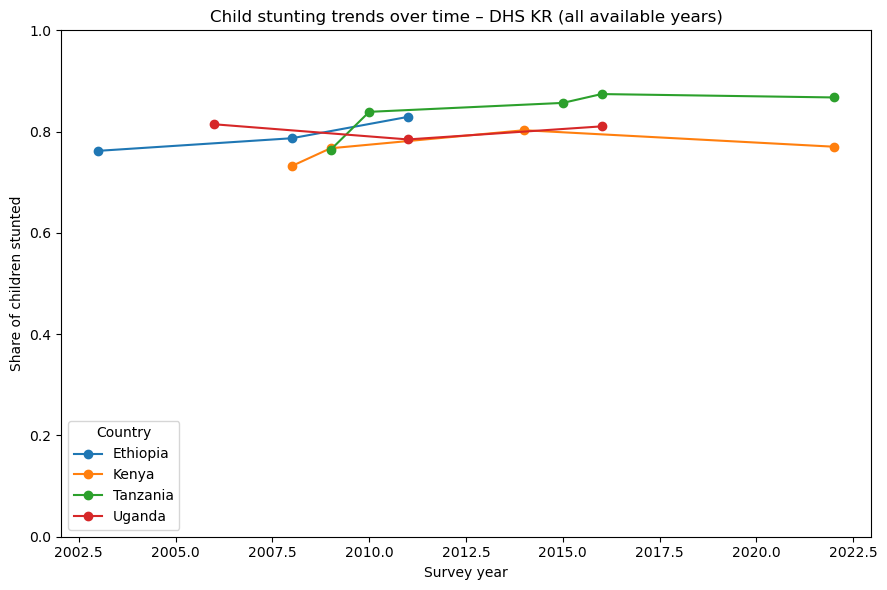

In [213]:
plt.figure(figsize=(9, 6))

for c in stunting_trend["country"].unique():
    tmp = stunting_trend[stunting_trend["country"] == c]
    plt.plot(tmp["survey_year"], tmp["stunted_rate"],
             marker="o", label=c)

plt.xlabel("Survey year")
plt.ylabel("Share of children stunted")
plt.title("Child stunting trends over time – DHS KR (all available years)")
plt.ylim(0, 1)
plt.legend(title="Country")
plt.tight_layout()
plt.show()


#####  For this next step we combine everything into one table and check years.We stack all the child records into a single data frame and look at which country year pairs we actually have.

##### Next step is making bar chart of stunting percent by wealth group for each country. This uses all the DHS KR years together for that country.